# Analiza Danych Obrazowych i Multimedialnych 
### Głębokie CNN - VGG (2014)
#### Miłosz Mertka, Sebastian Grosfeld, Kamil Jabłkowski, Paweł Borkowski
#### [Data realizacji ???]

### Sieć VGG - krótkie omówienie

Sieci VGG to zbiór konwolucyjnych sieci neuronowych opracowanych przez zespół badawczy Visual Geometry Group (VGG) na Uniwersytecie Oksfordzkim. Dzięki swojej prostocie oraz wysokiej skuteczności w zadaniach przetwarzania obrazów, architektury te znalazły szerokie zastosowanie w zadaniach z dziedziny widzenia komputerowego, obejmujące:
* klasyfikacja obrazów,
* detekcja obiektów,
* ekstrakcja cech obrazu.

Kluczową cechą sieci VGG jest stosowanie wielu małych filtrów o rozmiarach 3x3. Twórcy sieci VGG wykazali, że stosowanie większej liczby filtrów o niewielkim rozmiarze jest efektywniejsze niż stosowanie pojedynczych filtrów o większym rozmiarze. Takie podejście prowadzi do istotnej redukcji liczby parametrów, co znacząco skraca czas uczenia i ogranicza ryzyko przeuczenia. Co więcej, trzy kolejne warstwy konwolucyjne 3×3 zapewniają pole widzenia równoważne pojedynczej konwolucji 7×7, a jednocześnie umożliwiają wprowadzenie trzech nieliniowych transformacji (np. ReLU), co zwiększa zdolność modelu do uchwycenia złożonych zależności w danych.

W porównaniu z siecią AlexNet, która była przełomem w zadaniach z dziedziny widzenia komputerowego i stała się fundamentem dla późniejszych sieci konwolucyjnych, w przypadku sieci VGG stosuje się większą liczbę warstw splotowych, co pozwala na budowanie głębszych i bardziej złożonych reprezentacji cech obrazu. AlexNet składał się z 8 warstw uczących się (5 warstw konwolucyjnych i 3 w pełni połączonych), natomiast najpopularniejsze warianty VGG czyli VGG16 i VGG19 - zawierają odpowiednio 16 i 19 warstw. Dzięki temu sieci VGG mogły osiągać wyższą skuteczność klasyfikacji obrazów. 

Dodatkowo architektura VGG jest bardziej jednolita i uporządkowana niż AlexNet. Zamiast stosowania filtrów o różnych rozmiarach (np. 11×11 czy 5×5 jak w AlexNet), sieć VGG wykorzystuje niemal wyłącznie filtry 3×3 oraz warstwy poolingowe 2×2. Upraszcza to projektowanie architektury i poprawia zdolność modelu do generalizacji. Wadą sieci VGG jest jednak bardzo duża liczba parametrów, co wiąże się z wysokimi wymaganiami obliczeniowymi oraz dużym zużyciem pamięci podczas treningu.

#### Przydatne materiały
Publikacja źródłowa: 

- [Very Deep Convolutional Networks for Large-Scale Image Recognition
](https://arxiv.org/pdf/1409.1556).

Repozytorium kodu: 

- [PyTorch VGG Implementation](https://docs.pytorch.org/vision/main/models/vgg.html)

Tutoriale i omówienia:
- [Sieci neuronowe. Część IV: Głębokie sieci neuronowe” - Andrzej Pacut, Politechnika Warszawska, SNR, semestr zimowy 2020/2021](http://zbum.ia.pw.edu.pl/PL/dydaktyka/SNR/PUBLIC/SNR-czIV.pdf)

- [VGGNet - Wikipedia](https://en.wikipedia.org/wiki/VGGNet)

- [A Review of Popular Deep Learning Architectures: AlexNet, VGG16, and GoogleNet - Digital Ocean](https://www.digitalocean.com/community/tutorials/popular-deep-learning-architectures-alexnet-vgg-googlenet)

### Wykorzystana implementacja

W przeprowadzonych badaniach zastosowano model [vgg16](https://docs.pytorch.org/vision/main/models/generated/torchvision.models.vgg16.html#torchvision.models.vgg16) pochodzący z biblioteki PyTorch. Eksperymenty przeprowadzono zarówno z użyciem modelu z wstępnie wytrenowanymi wagami na zbiorze ImageNet‑1K jak i z użyciem modelu pozbawionym wag. Dodatkowo w badaniach wykorzystano również modele [AlexNet](https://docs.pytorch.org/vision/main/models/alexnet.html) oraz [GoogLeNet](https://docs.pytorch.org/vision/main/models/googlenet.html), w celu porównania efektywności działania sieci konwolucyjnych o różnych architekturach.

Na potrzeby realizacji badań opracowano również zestaw skryptów w języku Python, wspomagających przygotowanie danych, przeprowadzanie eksperymentów oraz analizę uzyskanych wyników:
1. `adom_images.py` - odpowiedzialny za przygotowanie i modyfikację obrazów testowych. Moduł umożliwia generowanie różnych wariantów obrazów poprzez dodawanie szumu Gaussowskiego, rozmycie, zmianę jasności i kontrastu, rotację oraz częściowe zasłanianie obiektów. Dodatkowo zawiera funkcje służące do zapisu, odczytu i wizualizacji przetworzonych obrazów, co pozwoliło na ocenę odporności badanych modeli na różnego rodzaju zakłócenia i degradacje danych wejściowych.
2. `adom_library.py` - moduł odpowiedzialny za obsługę modeli sieci neuronowych wykorzystywanych w badaniach. Zawiera funkcje służące do tworzenia, trenowania, ewaluacji, zapisywania i wczytywania modeli VGG16, AlexNet oraz GoogLeNet. Dodatkowo umożliwia zarządzanie zbiorami danych, konfigurację parametrów procesu uczenia oraz wizualizację wybranych elementów działania sieci konwolucyjnych.
3. `experiments_utils.py` - moduł odpowiedzialny za zbieranie metryk wydajnościowych podczas realizacji eksperymentów. Zawiera funkcje umożliwiające monitorowanie zużycia pamięci RAM i GPU, pomiar czasu wykonywania operacji, zarządzanie pamięcią oraz zapisywanie wyników pomiarów do plików CSV. Zebrane dane wykorzystano do analizy kosztów obliczeniowych badanych modeli sieci neuronowych.

### Przeprowadzone eksperymenty

#### 1. Porównanie VGG16, AlexNet i GoogLeNet

W eksperymencie porównano trzy architektury sieci CNN: VGG16, AlexNet oraz GoogLeNet. Wszystkie sieci zostały wcześniej dotrenowane w ten sam sposób w cyklu 10 epok na zbiorze CIFAR-10.

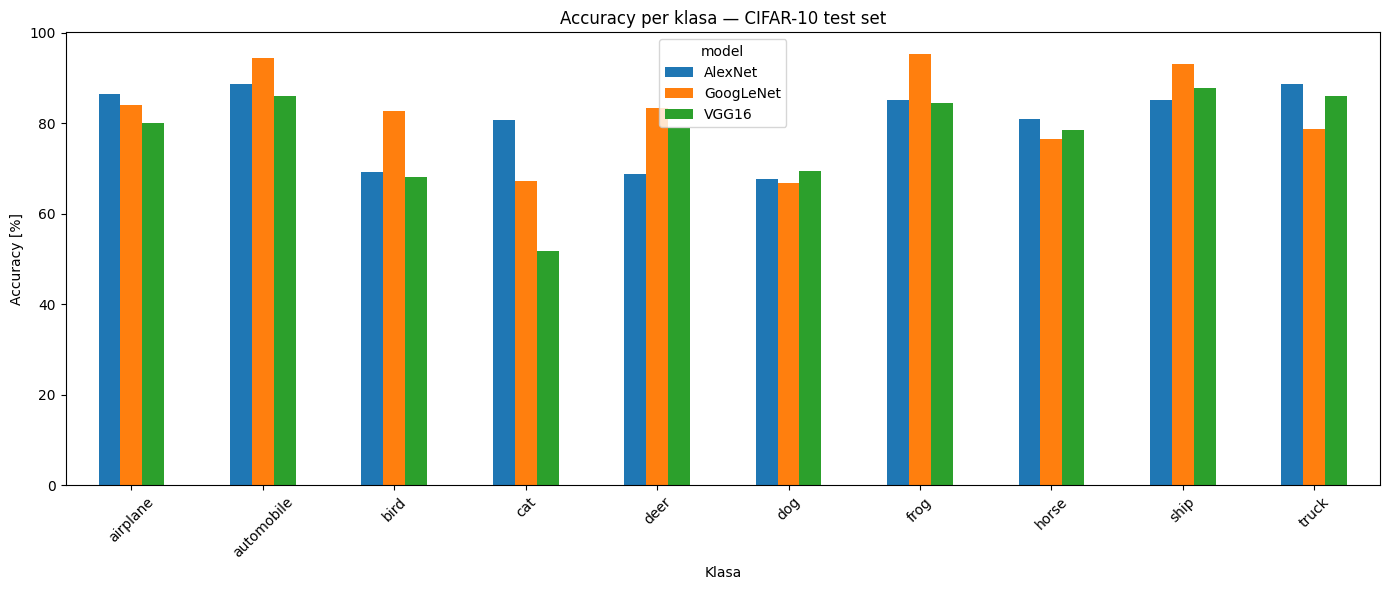

Na podstawie przeprowadzonych eksperymentów można stwierdzić, że najlepszym z badanych modeli okazał się GoogLeNet. Pomimo najmniejszej liczby parametrów, uzyskał najwyższą dokładność na zbiorze testowym CIFAR-10, najlepszą odporność na modyfikacje obrazu oraz bardzo dobre wyniki dla części obrazów zewnętrznych.

AlexNet osiągnął wyniki pośrednie. Był lepszy od VGG16 na zbiorze testowym CIFAR-10 i wykazał większą odporność na umiarkowany szum, ale miał duże problemy z obrotami obrazu.

VGG16, mimo największej liczby parametrów, uzyskał najniższą dokładność na zbiorze testowym CIFAR-10. Model dobrze radził sobie z częścią klas i prostszymi modyfikacjami obrazu, ale w niektórych przypadkach popełniał błędy z bardzo wysoką pewnością.

Eksperymenty pokazały, że liczba parametrów nie jest jedynym czynnikiem decydującym o jakości klasyfikacji. Ważniejsza okazała się efektywność architektury oraz sposób wykorzystania parametrów. Osiągnięte wyniki potwierdzają również, że modele klasyfikujące obrazy mogą być wrażliwe na silne przekształcenia i słabiej radzić sobie z obrazami spoza zbioru, na którym były trenowane.

##### Zbadano również wpływ modyfikacji obrazów na wynik klasyfikacji

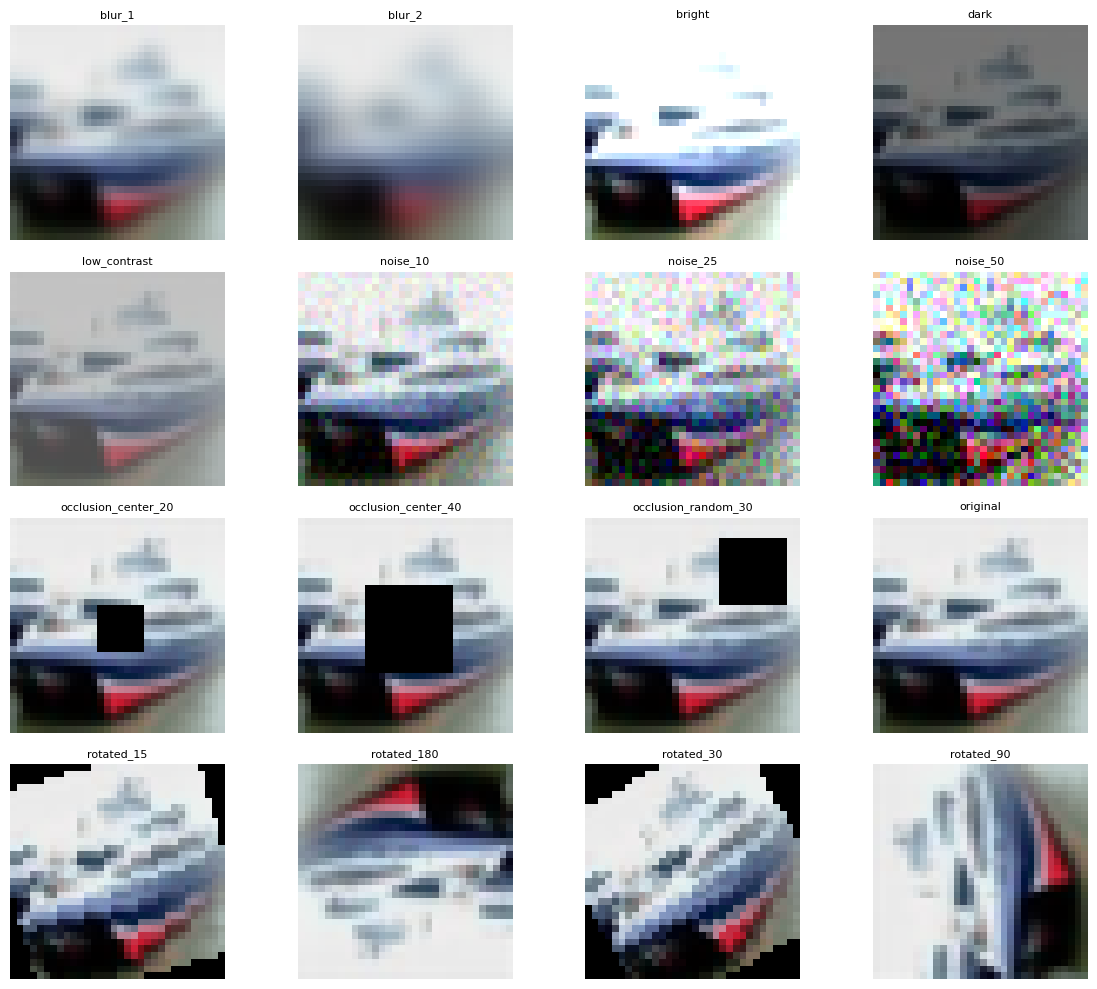

Modyfikacje obrazów obejmowały obrót, zmianę jasności i kontrastu, dodanie szumu, rozmycie oraz częściowe zasłanianie obiektów.

| Model     | Liczba poprawnych klasyfikacji | Liczba wariantów | Średnia pewność (%) | Skuteczność (%) |
| --------- | -----------------------------: | ---------------: | ------------------: | --------------: |
| GoogLeNet |                             12 |               16 |               83,43 |            75,0 |
| AlexNet   |                             10 |               16 |               49,95 |            62,5 |
| VGG16     |                             10 |               16 |               73,51 |            62,5 |

Najwyższą odporność na transformacje uzyskał GoogLeNet, który poprawnie sklasyfikował 12 z 16 wariantów obrazu (75%). AlexNet i VGG16 osiągnęły identyczny wynik – po 10 poprawnych klasyfikacji (62,5%).

GoogLeNet najlepiej radził sobie ze zmianą jasności i kontrastu oraz częściowym zasłanianiem obrazu. Pogorszenie wyników występowało głównie przy rozmyciu, dodaniu szumu i obrotach, jednak model nadal przewyższał pozostałe architektury.

VGG16 poprawnie klasyfikował obrazy po rozmyciu, zmianie jasności i kontrastu oraz przy niewielkich modyfikacjach geometrii obrazu. Problemy pojawiały się przy dodaniu szumu, większych obrotach oraz silnym zasłonięciu obiektu. W części błędnych klasyfikacji model wykazywał bardzo wysoką pewność, przekraczającą 99%, co wskazuje na tendencję do nadmiernej pewności błędnych decyzji.

AlexNet uzyskał taki sam ogólny wynik jak VGG16, jednak lepiej radził sobie z obrazami zawierającymi umiarkowany szum. Z kolei słabiej reagował na obroty – wszystkie obrócone warianty zostały sklasyfikowane niepoprawnie. W przeciwieństwie do VGG16 model ten wykazywał mniejszą pewność błędnych predykcji, a prawdopodobieństwo błędnej klasy nie przekraczało 80%.

Implementacja eksperymentów oraz kod wykorzystany do przeprowadzenia analiz znajdują się w pliku `experiments-comparison.ipynb`.


#### 2. Wpływ zmiany dropoutu na model VGG16 na zbiorze CIFAR-10

W eksperymencie porównano dwa warianty tego samego modelu VGG16 uczonego na zbiorze CIFAR-10. Pierwszy wariant miał dropout wyłączony, natomiast drugi wariant wykorzystywał dropout o zadanej wartości (0,5). Oba modele trenowano przez taką samą liczbę epok, tym samym optymalizatorem oraz na tym samym zbiorze danych.

Celem eksperymentu było sprawdzenie, czy zastosowanie dropout poprawia generalizację modelu (czyli wynik osiągany na danych testowych). Porównano dokładność na zbiorze treningowym oraz testowym. Szczególną uwagę zwrócono na różnicę między dokładnością treningową i testową, ponieważ może ona wskazywać na stopień przeuczenia modelu.

Jeżeli model z dropout osiąga niższy wynik treningowy, ale podobny lub lepszy wynik testowy, może to oznaczać, że dropout skutecznie ograniczył przeuczenie.

Wnioski:

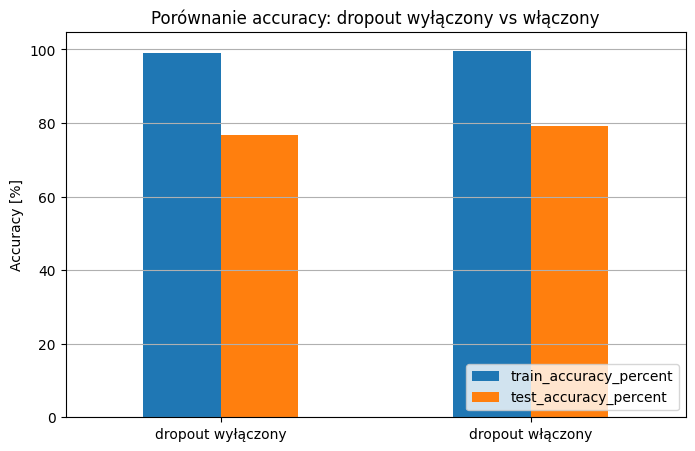

Po włączeniu dropout, można zaobserwować poprawę dokładności na zbiorze testowym z 76,63% do 79,24%, czyli o około 2,61 punktu procentowego, co sugeruje lepszą generalizację modelu.

Warto zauważyć, że zastosowanie dropout nie zmieniło liczby parametrów modelu (jest ta sama liczba parametrów). Oznacza to, że poprawa wyniku testowego nie wynikała ze zwiększenia pojemności sieci, lecz z działania mechanizmu regularizacji.

Dokładność na zbiorze treningowym w przypadku stosowania dropout może być niższa, jednak w przeprowadzonym eksperymencie osiągnięto wartość praktycznie identyczną (różnica mniejsza od 1%). Różnica między dokładnością treningową i testową nadal pozostaje duża, co wskazuje, że model wciąż wykazuje oznaki przeuczenia. Dropout zmniejszył jednak tę różnicę z około 22,39 p.p. do około 20,45 p.p., a jednocześnie poprawił dokładność testową z 76,63% do 79,24%. Można więc uznać, że w tym eksperymencie dropout poprawił generalizację modelu, jednak nie wyeliminował całkowicie problemu przeuczenia.

Implementacja eksperymentów oraz kod wykorzystany do przeprowadzenia analiz znajdują się w pliku `experiments-dropout.ipynb`.

#### 3. Analiza feature maps

Celem eksperymentu jest prosta analiza map cech generowanych przez wybrane warstwy konwolucyjne modeli VGG16 i AlexNet, które zostały wytrenowane na zbiorze CIFAR-10.

Eksperyment pokazuje, jak zmieniają się aktywacje w kolejnych częściach sieci:

- początkowe warstwy wykrywają proste cechy, np. krawędzie i kontrasty
- środkowe warstwy reagują na bardziej złożone wzory
- głębsze warstwy tworzą bardziej abstrakcyjne reprezentacje obrazu

Wnioski:

Wizualizacja map cech dla modelu VGG16:

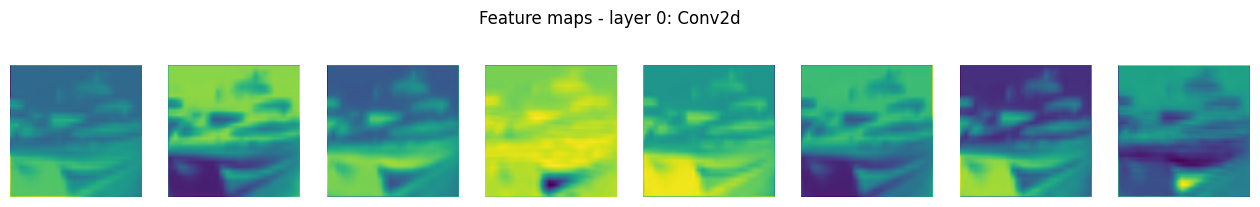

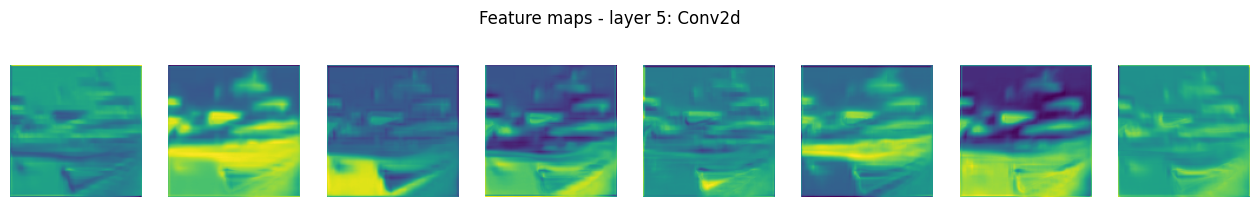

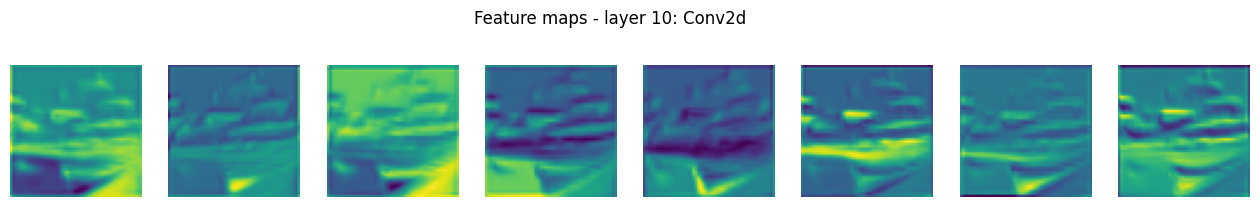

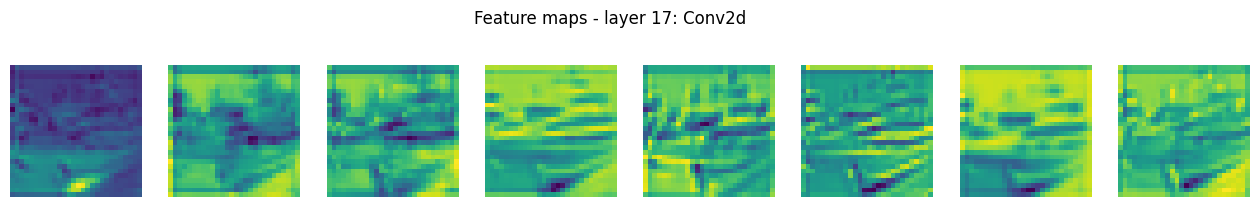

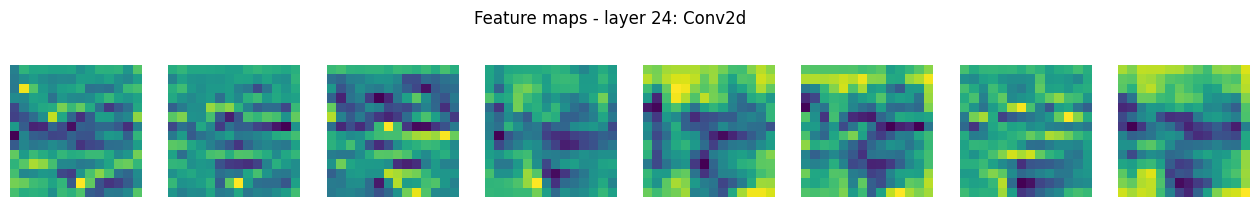

Wizualizacja map cech dla modelu AlexNet:

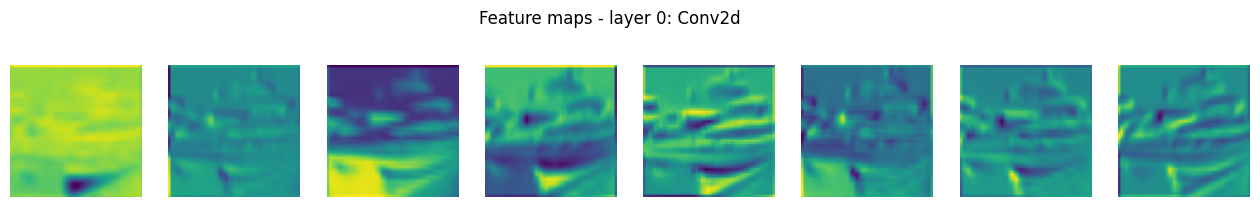

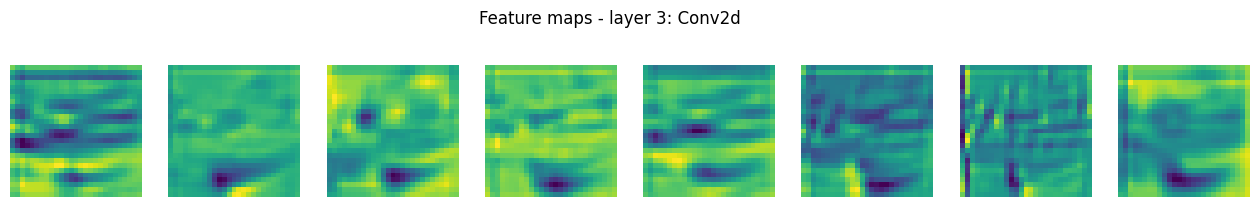

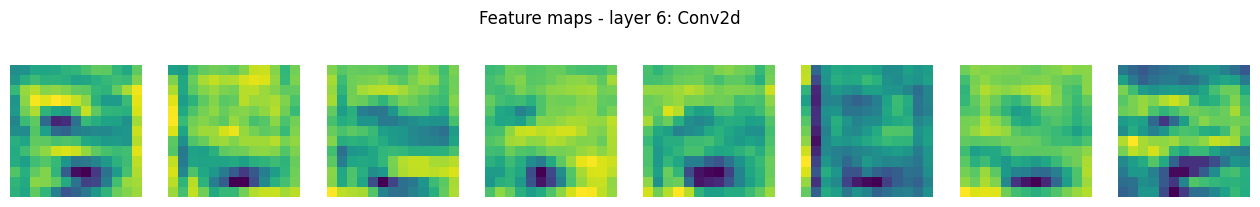

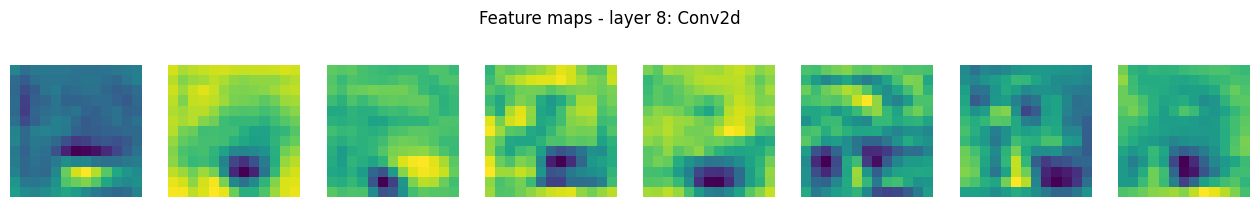

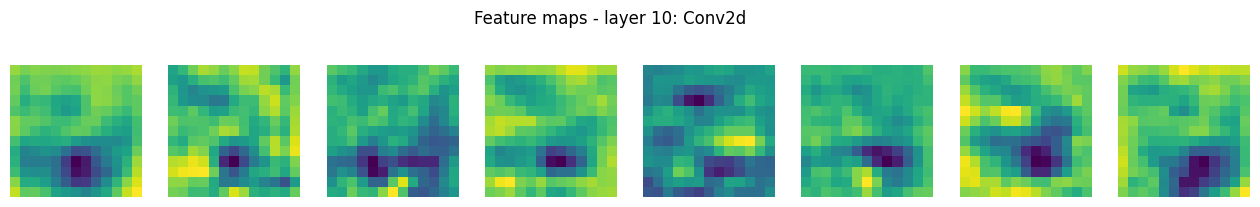

Przeprowadzona analiza feature maps pozwoliła prześledzić, jak zmienia się reprezentacja obrazu w kolejnych warstwach konwolucyjnych modeli VGG16 oraz AlexNet. Analizę przeprowadzono z wykorzystaniem wybranego obrazu ze zbioru testowego CIFAR-10, który został poprawnie sklasyfikowany przez oba modele. Obserwacja obejmowała aktywacje w kilku wybranych warstwach konwolucyjnych obu sieci.

W początkowych warstwach obu modeli mapy cech są jeszcze mocno powiązane z obrazem wejściowym. Możemy dostrzec proste informacje wizualne, takie jak krawędzie, kontury, podstawowe przejścia kolorów oraz ogólny układ obiektu. Oznacza to, że pierwsze warstwy pełnią rolę ekstraktora cech niskiego poziomu.

W kolejnych warstwach reprezentacje stają się coraz mniej podobne do oryginalnego obrazu. Aktywacje są bardziej selektywne i skupiają się na wybranych fragmentach obrazu, które mogą odpowiadać bardziej złożonym wzorcom lub częściom obiektu. W głębszych warstwach mapy cech są już trudniejsze do bezpośredniej interpretacji, ponieważ przedstawiają bardziej abstrakcyjne cechy wykorzystywane później przez klasyfikator.

Porównując VGG16 i AlexNet można zauważyć, że w przypadku AlexNet mapy cech szybciej tracą czytelne podobieństwo do obrazu wejściowego. Już po kilku warstwach aktywacje stają się bardziej rozpikselizowane i abstrakcyjne. Wynika to z płytszej architektury oraz zastosowania większych filtrów, które szybciej redukują szczegóły obrazu. W VGG16 przejście od prostych cech do bardziej abstrakcyjnych reprezentacji jest bardziej stopniowe, ponieważ sieć ma większą liczbę warstw konwolucyjnych oraz wykorzystuje mniejsze filtry 3×3. Dzięki temu VGG16 może stopniowo budować reprezentację obrazu i uwzględniać większą liczbę cech niż AlexNet. Małe filtry 3×3 umożliwiają dokładniejsze wychwytywanie lokalnych szczegółów, które przy większych filtrach, jak np. 11×11 w pierwszej warstwie AlexNet, mogą zostać szybciej uogólnione lub pominięte. Można to zaobserwować szczególnie w głębszych warstwach sieci: w mapach cech VGG16 aktywacje często zawierają kilka wyraźnych punktów lub obszarów, natomiast w AlexNet częściej pozostaje pojedyncza, bardziej ogólna aktywacja.

Można również zauważyć, że część map cech zawiera silne aktywacje, natomiast inne są prawie jednolite lub słabo pobudzone. Oznacza to, że nie wszystkie kanały danej warstwy są aktywne w takim samym stopniu. Wynika to z tego, że poszczególne filtry w warstwach konwolucyjnych specjalizują się w wykrywaniu różnych cech, które nie zawsze muszą występować w analizowanym obrazie.

Eksperyment potwierdził hierarchiczny charakter reprezentacji tworzonych przez sieci konwolucyjne. Początkowe warstwy wykrywają proste cechy wizualne, środkowe warstwy łączą je w bardziej złożone wzorce, a głębsze warstwy tworzą abstrakcyjne reprezentacje wykorzystywane do klasyfikacji obrazów CIFAR-10. Analiza pokazuje, że VGG16 tworzy bardziej szczegółowe, uporządkowane i stopniowo budowane reprezentacje obrazu, natomiast AlexNet szybciej przechodzi do bardziej ogólnych i mniej precyzyjnych aktywacji. Oznacza to, że VGG16 lepiej modeluje złożone wzorce wizualne, a AlexNet stanowi prostsze i mniej szczegółowe podejście do ekstrakcji cech.

Implementacja eksperymentów oraz kod wykorzystany do przeprowadzenia analiz znajdują się w pliku `experiments-feature-maps.ipynb`.

#### 4. Pomiar pamięci RAM i GPU

Celem eksperymentu jest sprawdzenie, jak zmienia się zużycie pamięci RAM i GPU podczas pracy z modelami VGG16 oraz AlexNet.

Eksperyment mierzy pamięć dla kilku etapów:

1. wczytanie zbioru CIFAR-10,
2. utworzenie modelu,
3. trening modelu,
4. ewaluacja modelu na zbiorze testowym.

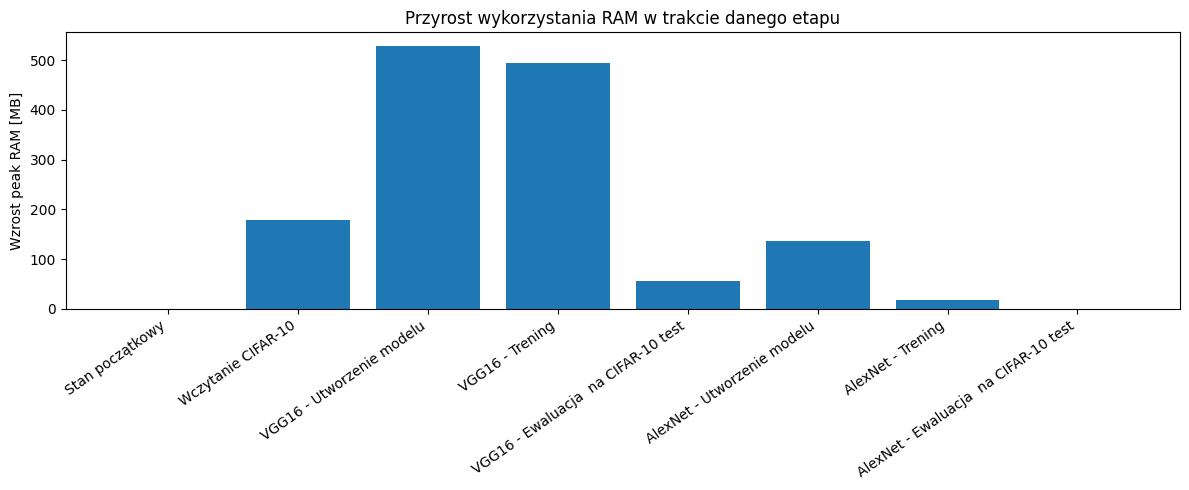

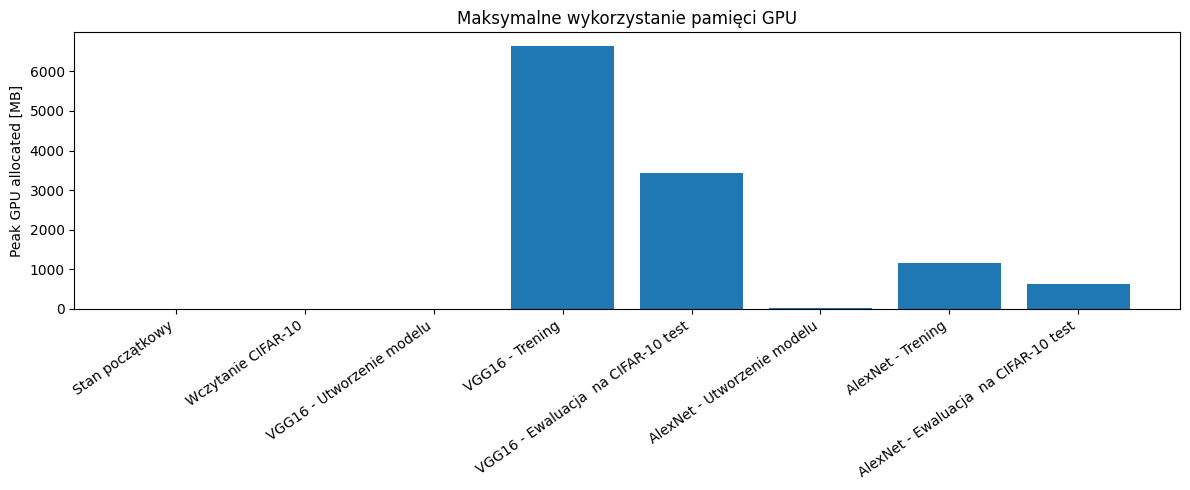


W przeprowadzonym eksperymencie porównano wykorzystanie pamięci RAM przez modele VGG16 oraz AlexNet podczas pracy na zbiorze CIFAR-10. Pomiar obejmował wczytanie danych, utworzenie modelu, trening oraz ewaluację na zbiorze testowym.

Etap wczytania zbioru CIFAR-10 wykazał, że pamięć RAM wzrosła o około 178 MB. Jest to stały koszt przygotowania danych, niezależny od wybranej architektury, ponieważ ten sam zbiór (CIFAR-10) był później wykorzystywany dla obu modeli.

Badania pamięci przy etapie tworzenia modelu wykazały, że największy wzrost pamięci RAM powoduje utworzenie modelu VGG16. Utworzenie tego modelu zwiększyło maksymalne użycie RAM o około 529 MB, natomiast dla AlexNet wzrost wyniósł około 137 MB. Oznacza to, że VGG16 potrzebował około 392 MB więcej od AlexNet. Wynika to z dużo większej liczby parametrów wykorzystywanych przy używaniu sieci VGG16 (około 134 mln) względem AlexNet (około 57 mln).

Etap treningu jest najbardziej wymagający pod względem wykorzystania pamięci RAM. W przypadku VGG16 maksymalne użycie RAM wzrosło o około 494 MB względem początku tego etapu, a maksymalne wykorzystanie pamięci GPU wyniosło około 6653 MB. Dla AlexNet wzrost RAM podczas treningu był znacznie mniejszy i wyniósł około 18 MB, a wykorzystanie pamięci GPU było równe w przybliżeniu 1153 MB. Na tej podstawie można stwierdzić, że VGG16 jest znacznie bardziej wymagający podczas treningu niż AlexNet. Różnicę tę możemy również zauważyć w przypadku czasu treningu - VGG16 potrzebował około 246 s na epokę, podczas gdy AlexNet tylko ok. 62 s.

Ewaluacja obu modeli była znacznie mniej wymagająca pamięciowo od etapu treningu. W przypadku VGG16 wzrost wykorzystania pamięci RAM podczas ewaluacji wyniósł około 56 MB, natomiast dla AlexNet był praktycznie pomijalny i wyniósł poniżej 1 MB. Wynika to z faktu, że podczas etapu ewaluacji model nie wykonuje propagacji wstecznej ani aktualizacji wag, więc nie musi przechowywać tylu dodatkowych danych pośrednich.

Wyniki ewaluacji na zbiorze testowym pokazały, że po jednej epoce treningu VGG16 uzyskał dokładność równą 60,68%, a AlexNet 57,08%. Różnica jakości była więc stosunkowo niewielka, mimo że VGG16 zużywał zdecydowanie więcej pamięci RAM, pamięci GPU oraz czasu treningu. Można więc stwierdzić, że większa architektura nie zawsze daje proporcjonalnie lepszy wynik, szczególnie przy krótkim treningu. Należy jednak zwrócić uwagę na fakt, że eksperyment wykonano tylko dla jednej epoki, dlatego uzyskane dokładności nie pokazują pełnego potencjału modeli. Wyniki są jednak wystarczające do porównania kosztu pamięciowego i obliczeniowego obu architektur.

Podsumowując, VGG16 jest modelem znacznie większym i bardziej kosztownym pamięciowo niż AlexNet. Różnicę zauważymy nie tylko w większej liczbie parametrów i ilości zajmowanej pamięci, ale także w znacznie dłuższym czasie treningu. Eksperyment potwierdza, że przy porównywaniu architektur CNN należy analizować nie tylko dokładność (accuracy), ale również koszt pamięciowy i czas treningu.

Implementacja eksperymentów oraz kod wykorzystany do przeprowadzenia analiz znajdują się w pliku `experiments-ram-analysis.ipynb`.

#### 5. Badania fine-tuning

Celem eksperymentu jest porównanie kilku strategii dostrajania modelu:

1. model pretrained przed fine-tuningiem
2. trenowanie samego klasyfikatora
3. fine-tuning ostatnich warstw konwolucyjnych
4. pełny fine-tuning całego modelu

W eksperymencie wykorzystano model VGG16 z wagami pretrained ImageNet. Ostatnia warstwa klasyfikatora została zastąpiona warstwą dopasowaną do 10 klas zbioru CIFAR-10. Porównano trzy strategie fine-tuningu: trenowanie samego klasyfikatora, fine-tuning ostatnich warstw konwolucyjnych oraz pełny fine-tuning całej sieci.

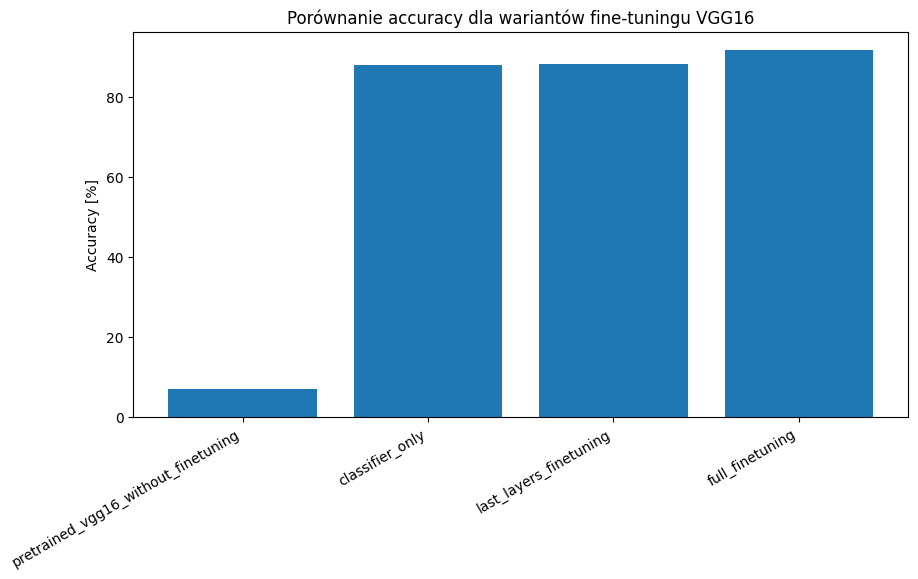

Wyniki pokazały, że samo wykorzystanie wag ImageNet bez dostrojenia klasyfikatora nie jest wystarczające. Model przed fine-tuningiem osiągnął jedynie 6,85% accuracy, ponieważ nowa warstwa klasyfikująca była losowo zainicjalizowana i nie była jeszcze dopasowana do klas CIFAR-10. Możemy to zaobserwować również po predykcjach dla przykładowego obrazu, gdzie poprawna klasa nie była wskazana jako najbardziej prawdopodobna, a wartości pewności (accuracy) były niskie i zbliżone do siebie.

Trenowanie klasyfikatora pozwoliło dopasować klasy CIFAR-10 do cech nauczonych na ImageNet, co znacznie poprawiło wyniki (osiągnięto 87,87% accuracy). Oznacza to, że cechy wyuczone wcześniej na ImageNet są w dużym stopniu przydatne również dla CIFAR-10, nawet bez modyfikowania części konwolucyjnej modelu.

Fine-tuning ostatnich warstw konwolucyjnych dał nieco lepszy wynik, ponieważ umożliwił modelowi dostosowanie głębszych reprezentacji do specyfiki CIFAR-10. Osiągnięto dzięki temu 88,23% accuracy, jednak niewielka poprawa sugeruje, że przy krótkim treningu i zastosowanym learning rate samo odmrożenie ostatniego bloku konwolucyjnego nie daje bardzo dużego zysku jakościowego.

Po pełnym fine-tuningu sieci uzyskaliśmy najlepsze wyniki. Model osiągnął 91,65% accuracy oraz najniższy test loss spośród badanych wariantów. Pełny fine-tuning zapewnił największą elastyczność, ponieważ wszystkie warstwy mogły dostosować swoje reprezentacje do zbioru CIFAR-10. Zysk jakościowy wiązał się jednak z największym kosztem obliczeniowym i pamięciowym.

Analizując czas treningu widzimy, że trening samego klasyfikatora trwał około 363 s, fine-tuning ostatnich warstw około 370 s, natomiast pełny fine-tuning około 4116 s. Oznacza to, że pełny fine-tuning był ponad 11 razy wolniejszy od pozostałych wariantów, mimo że poprawił accuracy względem trenowania samego klasyfikatora o jedynie ok. 3,78 punktu procentowego.

Podobną zależność można zaobserwować w użyciu pamięci GPU, gdzie odmrożenie większej liczby parametrów zwiększyło wyraźnie koszt pamięciowy (wzrost wykorzystywanej pamięci o nawet 4 GB). Wynika to z konieczności przechowywania większej liczby gradientów podczas treningu.

Analiza feature maps wskazała, że wczesne warstwy przechowują bardziej ogólne cechy obrazu, takie jak krawędzie, proste kształty i tekstury. Głębsze warstwy zawierają bardziej abstrakcyjne reprezentacje, które są silniej związane z zadaniem klasyfikacji. Różnice pomiędzy wariantami fine-tuningu są szczególnie widoczne właśnie w głębszych warstwach, ponieważ to one odpowiadają za bardziej semantyczną interpretację obrazu. 

Podsumowując, eksperyment pokazał, że pełny fine-tuning najbardziej poprawia jakość klasyfikacji, jednak wiąże się on z największym kosztem obliczeniowym i pamięciowym. Pozostałe omawiane warianty trenowania są znacznie szybsze, jak również wymagają znacznie mniej pamięci. Są więc dobrym kompromisem w sytuacji, gdy dostępne zasoby są ograniczone.

Implementacja eksperymentów oraz kod wykorzystany do przeprowadzenia analiz znajdują się w pliku `experiments-fine-tuning.ipynb`.

### Wnioski

W przypadku porównania architektur (VGG16, AlexNet, GoogLeNet) najlepsze wyniki uzyskał GoogLeNet, mimo najmniejszej liczby parametrów. Oznacza to, że sama wielkość modelu nie gwarantuje lepszej jakości - kluczowa jest efektywność architektury. VGG16, mimo dużej liczby parametrów, okazał się najmniej efektywny, co sugeruje, że jest on mniej opłacalny w sytuacjach, gdzie liczy się wydajność lub ograniczone zasoby.

Analiza wpływu dropout pokazała, że metoda ta jest skuteczna w ograniczaniu przeuczenia i poprawie generalizacji, szczególnie gdy model ma tendencję do nadmiernego dopasowania do danych treningowych. Dropout sprawdza się więc jako prosta metoda regularizacji, która nie zwiększa liczby parametrów ani kosztu uczenia. Jednocześnie jego wpływ nie jest znaczący i nie eliminuje całkowicie problemu overfittingu, a jedynie go redukuje. W bardziej wymagających przypadkach powinien być łączony z innymi metodami.

Analiza feature maps potwierdziła, że sieci CNN uczą się hierarchicznych reprezentacji, co jest szczególnie widoczne w VGG16. Metoda ta ma głównie charakter diagnostyczny - sprawdza się w analizie i interpretacji działania modeli, ale nie wpływa bezpośrednio na ich jakość. Jest szczególnie użyteczna w porównywaniu architektur i wykrywaniu różnic w sposobie ekstrakcji cech, natomiast nie jest metodą poprawy wyników.

Pomiar pamięci RAM i GPU pokazał, że bardziej złożone modele (np. VGG16) są znacznie bardziej kosztowne obliczeniowo, przy relatywnie niewielkim wzroście jakości. Oznacza to, że w zastosowaniach praktycznych VGG16 sprawdza się głównie wtedy, gdy dostępne są duże zasoby sprzętowe i czas nie jest krytyczny. W przeciwnym razie bardziej efektywne są lżejsze architektury, które oferują lepszy stosunek jakości do kosztu.

Eksperymenty z fine-tuningiem pokazały, że jest to najskuteczniejsza metoda poprawy jakości modeli pretrenowanych, szczególnie gdy dane docelowe różnią się od danych źródłowych. Pełny fine-tuning daje najlepsze wyniki, ale jest bardzo kosztowny i czasochłonny, dlatego sprawdza się głównie w sytuacjach, gdzie priorytetem jest maksymalna jakość. Trenowanie samego klasyfikatora lub końcowych warstw stanowi zatem kompromis przy ograniczonych zasobach.

Podsumowując, eksperymenty pokazują, że:

- lekkie architektury (np. GoogLeNet) są najbardziej efektywne praktycznie,
- dropout jest prostą metodą nieznacznej redukcji overfittingu,
- kosztowne modele (np. VGG16) wymagają uzasadnienia w kontekście dostępnych zasobów,
- fine-tuning jest dobrą metodą na poprawę jakości działania modelu, ale jego pełna wersja jest opłacalna tylko w wybranych przypadkach.
